In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
import os
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from transformers import AutoImageProcessor, AutoModelForDepthEstimation, ViTImageProcessor

from zesco.dataset import PairedImagesDataset, sample_cvusa_images, get_transforms, denormalize
from zesco.model import CrossviewModel, CosineSimilarityLoss, get_combined_embedding_visualization_all, get_processors
from zesco.inoutdoor import IndoorOutdoorClassifier
from zesco.depther import DepthAnything, get_radial_depth_map
from zesco.skyfilter import SkyFilter
from zesco.utils import get_direction_tokens, get_averaged_vertical_tokens, get_averaged_radial_tokens, find_alignment

Running on: cuda | GPU Acceleration: True


In [2]:
visualizations_path = r'..\utils\visualizations'

In [3]:
# Sample paired images
# dataset_path = r"D:\cross_view_localization_DSM\Data\CVGlobal"
dataset_path = r"D:\cross_view_localization_DSM\Data\CVUSA"
train_filenames, val_filenames = sample_cvusa_images(dataset_path, sample_percentage=0.2, split_ratio=0.8, groundtype='panos')

# Settings
image_size = 224*2
aerial_scaling = 2
provide_paths = False
BATCH_SIZE = 1
fov_x = 90                   # horizontal fov in degrees
num_layers = 1
crop_percentage = 0.3
horizontal_scaling = round(fov_x / 90.0) if fov_x >= 90 else 1.0

backbone = 'dinov3'

# Get the processor and transforms
processors = get_processors(backbone)
transform_ground, transform_aerial = get_transforms(processors, image_size, aerial_scaling, crop_percentage=crop_percentage, horizontal_scaling=horizontal_scaling)

# Instantiate the dataset and dataloader
paired_dataset = PairedImagesDataset(train_filenames, transform_aerial=transform_aerial, transform_ground=transform_ground, cutout_from_pano=True, fov_x=fov_x, debug=True)
data_loader = DataLoader(paired_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Define the Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load IndoorOutdoorClassifier
indoor_outdoor_classifier = IndoorOutdoorClassifier().to(device)

# Load the Model
model = CrossviewModel(backbone=backbone, frozen=True).to(device)
grid_size_ground = (image_size // model.patch_size, image_size // model.patch_size * horizontal_scaling)
grid_size_aerial = (image_size // model.patch_size, image_size // model.patch_size)
# grid_dim = grid_size[0] if grid_size[0] == grid_size[1] else ValueError("Grid size should be square.")
print(f"Model patch size: {model.patch_size}, grid size ground: {grid_size_ground}, grid size aerial: {grid_size_aerial}")
model.show()

Using device: cuda
Model patch size: 16, grid size ground: (28, 28), grid size aerial: (28, 28)



CrossviewModel(
  (model): DINOv3ViTModel(
    (embeddings): DINOv3ViTEmbeddings(
      (patch_embeddings): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (rope_embeddings): DINOv3ViTRopePositionEmbedding()
    (layer): ModuleList(
      (0-23): 24 x DINOv3ViTLayer(
        (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attention): DINOv3ViTAttention(
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (o_proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (layer_scale1): DINOv3ViTLayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): DINOv3ViTMLP(
          (up

Pano Shape: 224x1232
Center coordinates: x=677.6, y=112.0
FOV: 308x224
Cutout coordinates (before wrapping): x1=523, x2=831, y1=0, y2=224
Clamped y coordinates: y1=0, y2=224


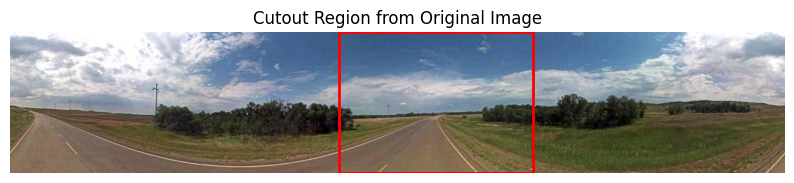

fov: (90, 180)
yaw: 198
pitch: 90
ground tokens shape: torch.Size([1, 784, 1024])
aerial tokens shape: torch.Size([1, 784, 1024])
num_patches_ground:  784
num_patches_aerial:  784
Ground image pixel values (min, max): 0.0 0.9176471
Aerial image pixel values (min, max): 0.0 1.0
ground tokens shape: torch.Size([1, 784, 1024])
aerial tokens shape: torch.Size([1, 784, 1024])
num_patches_ground:  784
num_patches_aerial:  784
Ground image pixel values (min, max): 0.0 0.9176471
Aerial image pixel values (min, max): 0.0 1.0
Outdoor Probability: 99.9%
Outdoor Probability: 99.9%


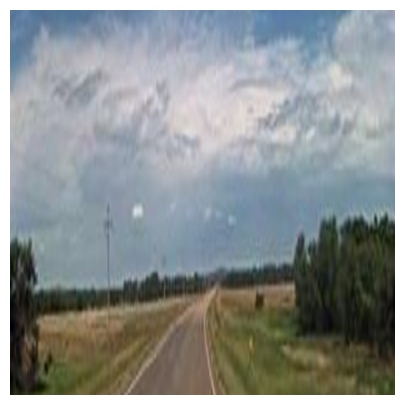

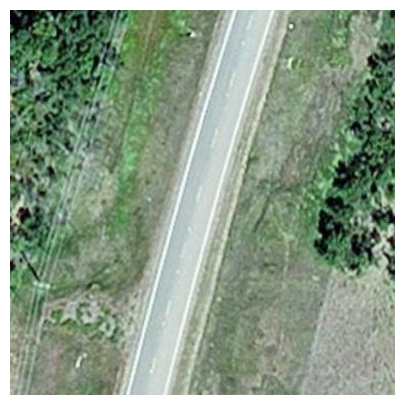

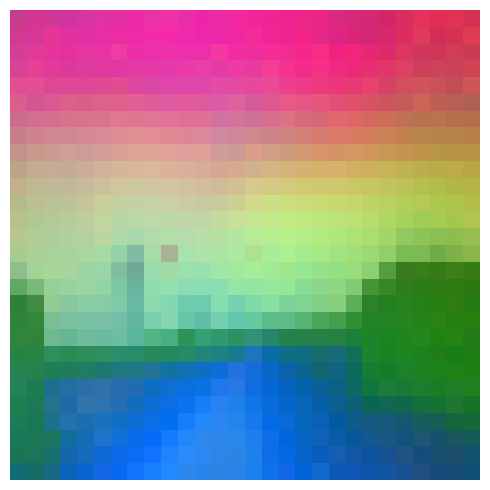

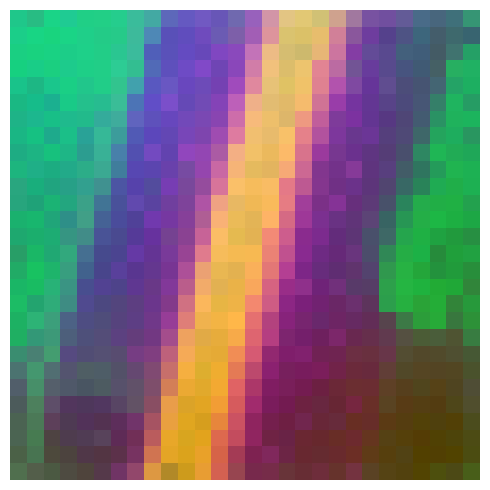

In [4]:
# Load a single pair of images
ground_image, aerial_image, fov, yaw, pitch = next(iter(data_loader))
ground_image = ground_image.to(device)
aerial_image = aerial_image.to(device)

print("fov:", (fov[0].item(), fov[1].item()))
print("yaw:", yaw.item())
print("pitch:", pitch.item())

# Compute the output of the model
ground_tokens, aerial_tokens = model(ground_image, aerial_image, debug=True)

print("ground tokens shape:", ground_tokens.shape)
print("aerial tokens shape:", aerial_tokens.shape)

# Calculate the number of patches for ground and aerial images
num_patches_ground = (ground_image.shape[-1] // model.patch_size) * (ground_image.shape[-2] // model.patch_size)
num_patches_aerial = (aerial_image.shape[-1] // model.patch_size) * (aerial_image.shape[-2] // model.patch_size)
print("num_patches_ground: ", num_patches_ground)
print("num_patches_aerial: ", num_patches_aerial)

ground_image_denorm = denormalize(ground_image.squeeze(), processors[0])
aerial_image_denorm = denormalize(aerial_image.squeeze(), processors[1])

# Convert images to numpy for visualization
ground_image_np = ground_image_denorm.permute(1, 2, 0).detach().cpu().numpy()
aerial_image_np = aerial_image_denorm.permute(1, 2, 0).detach().cpu().numpy()
ground_image_vis = ground_image_np * 255
aerial_image_vis = aerial_image_np * 255
ground_image_vis = ground_image_vis.astype(np.uint8)
aerial_image_vis = aerial_image_vis.astype(np.uint8)

print("Ground image pixel values (min, max):", ground_image_np.min(), ground_image_np.max())
print("Aerial image pixel values (min, max):", aerial_image_np.min(), aerial_image_np.max())

# Check for Indoor or Outdoor Image
with torch.no_grad():
    # Convert ground image to PIL Image for the classifier
    ground_image_pil = transforms.ToPILImage()(ground_image_denorm.cpu())
    ground_preds = indoor_outdoor_classifier(ground_image_pil)

print(f"Outdoor Probability: {ground_preds['Outdoor']*100}%")

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(ground_image_np)
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "ground_image.png"), bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(aerial_image_np)
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "aerial_image.png"), bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

ground_vis_tokens = model.show_tokens(ground_tokens, grid_size=grid_size_ground, mode='save', results_path=os.path.join(visualizations_path, "ground_tokens.png"), return_tokens=True)
aerial_vis_tokens = model.show_tokens(aerial_tokens, grid_size=grid_size_aerial, mode='save', results_path=os.path.join(visualizations_path, "aerial_tokens.png"), return_tokens=True)

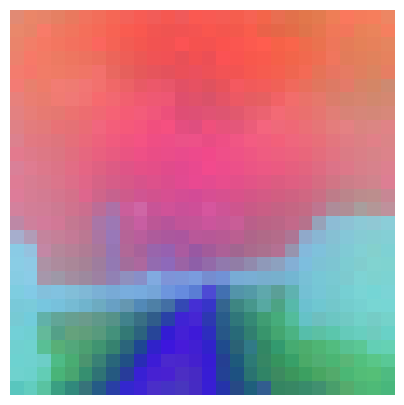

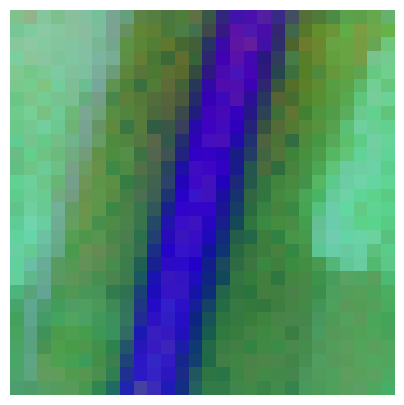

In [5]:
# Visualization - Common Baselined Tokens Combined
ground_features = ground_tokens.squeeze(0).detach().cpu().numpy()
aerial_features = aerial_tokens.squeeze(0).detach().cpu().numpy()
ground_features_combined, aerial_features_combined = model.get_combined_embedding_visualization(ground_features, aerial_features, grid_size_ground, grid_size_aerial)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(ground_features_combined)
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "ground_features_combined.png"), bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(aerial_features_combined)
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "aerial_features_combined.png"), bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

#### Apply the Sky Filter

using provider: CUDAExecutionProvider


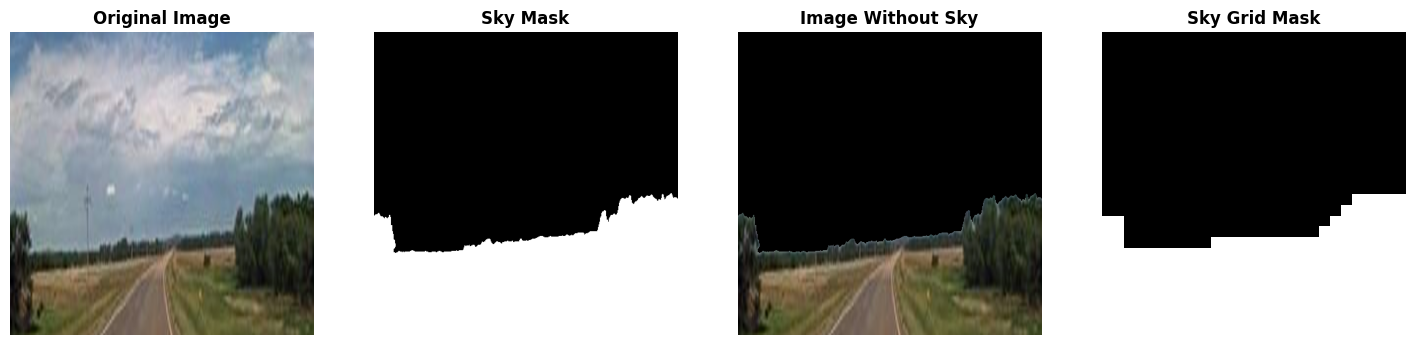

In [6]:
# Initialize the sky filter
sky_filter = SkyFilter(grid_size=grid_size_ground)

# Apply the sky filter
ground_image_no_sky, sky_mask, sky_grid = sky_filter(ground_image_vis, debug=False)

# Visualize the original image, mask, and the sky-removed image
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 6))
ax1.imshow(ground_image_vis)
ax1.set_title("Original Image", fontsize=12, fontweight='bold')
ax1.axis('off')
    
ax2.imshow(sky_mask, cmap='gray')
ax2.set_title("Sky Mask", fontsize=12, fontweight='bold')
ax2.axis('off')

ax3.imshow(ground_image_no_sky)
ax3.set_title("Image Without Sky", fontsize=12, fontweight='bold')
ax3.axis('off')

ax4.imshow(sky_grid, cmap='gray')
ax4.set_title("Sky Grid Mask", fontsize=12, fontweight='bold')
ax4.axis('off')

plt.show()

ground_vis_tokens.shape:  (1, 28, 28, 3)
sky_grid.shape:  (28, 28)
ground_image_vis.shape:  (448, 448, 3)
model.patch_size:  16
ground_tokens_no_sky.shape:  (1, 28, 28, 3)


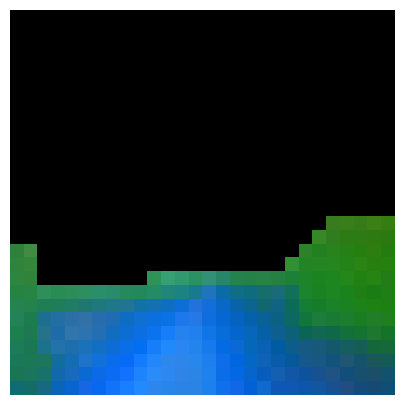

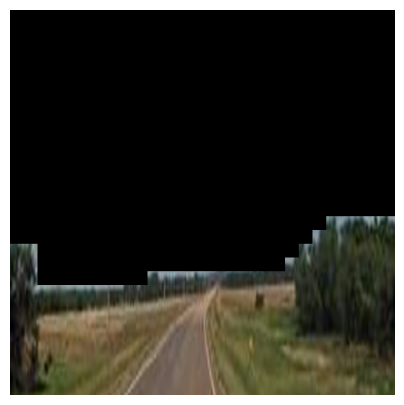

In [7]:
print("ground_vis_tokens.shape: ", ground_vis_tokens.shape)
print("sky_grid.shape: ", sky_grid.shape)
print("ground_image_vis.shape: ", ground_image_vis.shape)
print("model.patch_size: ", model.patch_size)

# Show Ground Tokens without Sky
ground_tokens_no_sky = ground_vis_tokens * sky_grid.reshape(1, sky_grid.shape[0], sky_grid.shape[1], 1)

# Create a figure in which the grid mask is applied to the original image
ground_image_tokenized_no_sky = ground_image_vis * sky_grid.reshape(sky_grid.shape[0], sky_grid.shape[1], 1).repeat(16, axis=0).repeat(16, axis=1)
print("ground_tokens_no_sky.shape: ", ground_tokens_no_sky.shape)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(ground_tokens_no_sky.squeeze(0))
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "ground_tokens_no_sky.png"), bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(ground_image_tokenized_no_sky)
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "ground_image_no_sky.png"), bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()
        

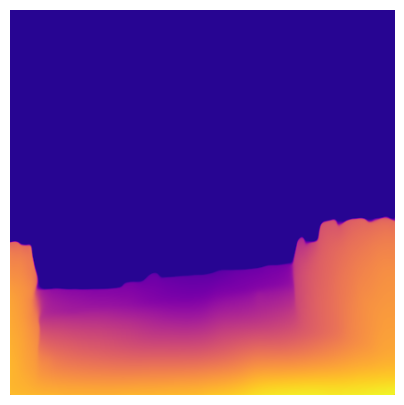

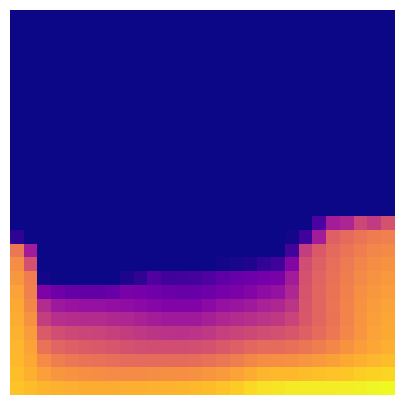

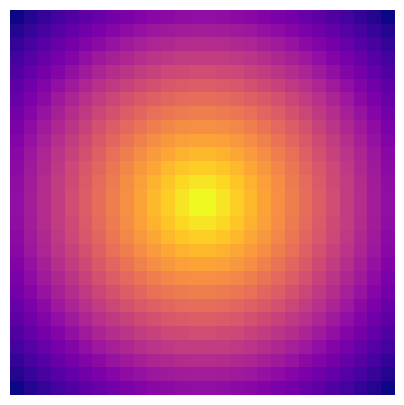

In [8]:
# Compute Depth Maps
depth_anything = DepthAnything(grid_size=grid_size_ground)

depth_map_ground, depth_map_grid_ground = depth_anything(ground_image_no_sky, debug=False)
depth_map_grid_aerial = get_radial_depth_map(grid_size_aerial)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(depth_map_ground, cmap='plasma')
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "depth_map.png"), dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(depth_map_grid_ground, cmap='plasma')
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "depth_map_ground.png"), dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(depth_map_grid_aerial, cmap='plasma')
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "depth_map_aerial.png"), dpi=300, bbox_inches='tight')
plt.show()

angle_step:  3.2142857142857144
averaged vertical tokens:  (1, 28, 1024)
averaged radial tokens:  (1, 112, 1024)
Delta yaw:  1.9285714285714448
Confidence: 2.6445
len(angles):  112
len(distances):  112


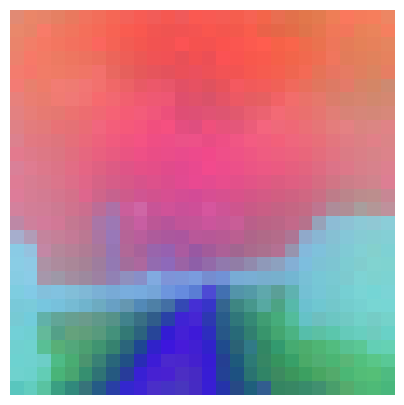

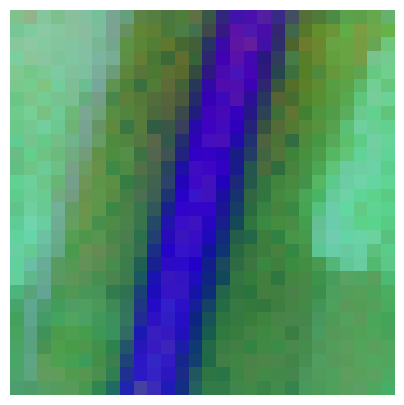

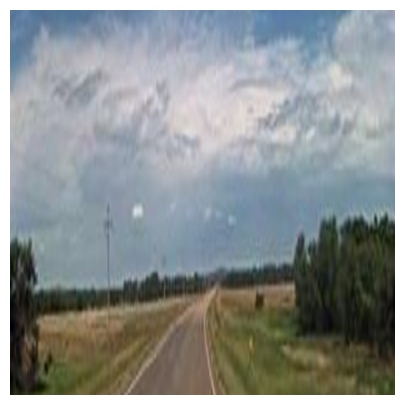

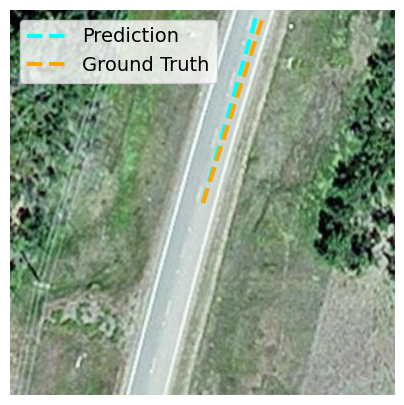

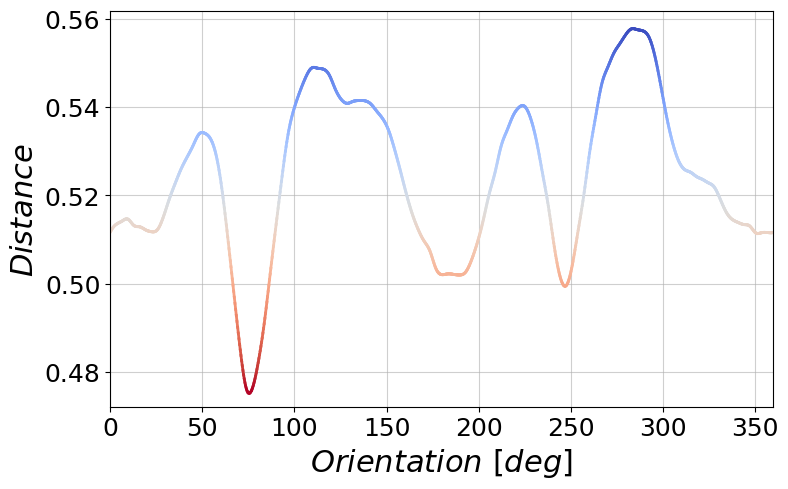

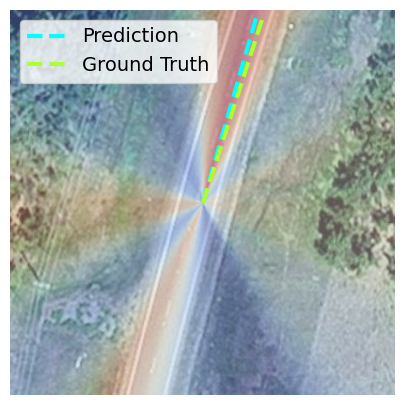

Plots saved to ..\utils\visualizations


In [9]:
# Define Angle Step
angle_step = fov_x / grid_size_ground[1]    # should be always 6.4285 degrees for 224x224
print("angle_step: ", angle_step)

loss = CosineSimilarityLoss()

# Compute Averaged Tokens using the weight vector, excluding sky tokens
vertical_averaged_tokens = get_averaged_vertical_tokens(
    angle_step=angle_step,
    image_tokens=ground_features,
    grid_size=grid_size_ground,
    sky_grid=sky_grid,
    depth_map_grid=depth_map_grid_ground,
    num_layers=num_layers,
    debug=False
)
radial_averaged_tokens = get_averaged_radial_tokens(
    angle_step=angle_step,
    image_tokens=aerial_features,
    grid_size=grid_size_aerial,     # use height for square aerial grid
    sky_grid=sky_grid,
    depth_map_grid=depth_map_grid_aerial,
    num_layers=num_layers,
    debug=False
)
print("averaged vertical tokens: ", vertical_averaged_tokens.shape)
print("averaged radial tokens: ", radial_averaged_tokens.shape)

# Find the best alignment - pass grid_size_ground tuple (will use width for alignment)
best_orientation, distances, min_distance, confidence = find_alignment(loss, vertical_averaged_tokens, radial_averaged_tokens, grid_size_ground, fov_x, debug=False)
delta_yaw = np.abs(((90 - (yaw.item() - 180)) - best_orientation + 180) % 360 - 180)
if delta_yaw < 0:
    delta_yaw += 180

print("Delta yaw: ", delta_yaw)
print(f"Confidence: {confidence:.4f}")

num_steps = int(round(360 / angle_step))
angles = np.linspace(0, 360 - angle_step, num_steps)
print("len(angles): ", len(angles))
print("len(distances): ", len(distances))

# Interpolate for smoother curves
from scipy.interpolate import interp1d
angles_fine = np.linspace(0, 360, 1000)
interpolator = interp1d(np.append(angles, 360), np.append(distances, distances[0]), kind='cubic')
distances_fine = interpolator(angles_fine)

# Use coolwarm colormap for better contrast (reversed so blue = low distance = good match)
cmap = plt.cm.coolwarm_r

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(ground_features_combined)
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "ground_features_combined.png"), bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(aerial_features_combined)
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "aerial_features_combined.png"), bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

# Plot 1: Ground Image
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(ground_image_np)
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "plot_ground_image.png"), dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Aerial Image with prediction and ground truth lines
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(aerial_image_np)
radius = aerial_image_np.shape[0] // 2
center = (aerial_image_np.shape[1] // 2, aerial_image_np.shape[0] // 2)
end_x = int(center[0] + radius * np.cos(np.deg2rad(best_orientation)))
end_y = int(center[1] - radius * np.sin(np.deg2rad(best_orientation)))
end_x_GT = int(center[0] + radius * np.cos(np.deg2rad(90 - (yaw.item() - 180))))
end_y_GT = int(center[1] - radius * np.sin(np.deg2rad(90 - (yaw.item() - 180))))
line_pred = ax.plot([center[0], end_x], [center[1], end_y], color='#00FFFF', linestyle='--', label='Prediction', linewidth=3)
line_gt = ax.plot([center[0], end_x_GT], [center[1], end_y_GT], color='orange', linestyle='--', label='Ground Truth', linewidth=3)
ax.legend(loc='best', fontsize=14)
ax.axis('off')
plt.savefig(os.path.join(visualizations_path, "plot_aerial_orientation.png"), dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Distance curve with color-coded points
fig, ax3 = plt.subplots(1, 1, figsize=(8, 5))
min_dist = min(distances)
max_dist = max(distances)

# Create smooth colored line
colors_fine = [cmap((d - min_dist) / (max_dist - min_dist)) for d in distances_fine]
for i in range(len(angles_fine) - 1):
    ax3.plot(angles_fine[i:i+2], distances_fine[i:i+2], color=colors_fine[i], linewidth=2)

# set the ticks values font size
ax3.tick_params(axis='x', labelsize=18)
ax3.tick_params(axis='y', labelsize=18)
ax3.grid(True, alpha=0.6)
ax3.set_xlabel('$Orientation \ [deg]$', fontsize=22)
ax3.set_ylabel('$Distance$', fontsize=22)
ax3.set_xlim(0, 360)
# Add some padding to y-axis to ensure curve fits
y_range = max_dist - min_dist
ax3.set_ylim(min_dist - 0.05 * y_range, max_dist + 0.05 * y_range)
plt.tight_layout()
plt.savefig(os.path.join(visualizations_path, "plot_distance_curve.png"), dpi=300, bbox_inches='tight')
plt.show()

# Create a polar heatmap with fine-grained interpolation
img_size = aerial_image_np.shape[0]
Y, X = np.ogrid[:img_size, :img_size]
center_y, center_x = img_size // 2, img_size // 2

# Calculate angle for each pixel to match the convention: angle=0 is +x axis, angle increases counterclockwise
# Using the same convention as get_direction_tokens: x = center_x + r*cos(angle), y = center_y - r*sin(angle)
dx = X - center_x
dy = center_y - Y  # Note: inverted because y increases downward in image coordinates
angles_grid = np.arctan2(dy, dx) * 180 / np.pi  # arctan2(dy, dx) gives angle from +x axis
angles_grid = angles_grid % 360  # Convert to [0, 360)

# Use interpolation to get smooth distance values
interpolator_heatmap = interp1d(np.append(angles, 360), np.append(distances, distances[0]), 
                                 kind='cubic', fill_value='extrapolate')

# Map each pixel to its corresponding distance value using interpolation
heatmap = np.zeros((img_size, img_size))
for i in range(img_size):
    for j in range(img_size):
        pixel_angle = angles_grid[i, j]
        heatmap[i, j] = interpolator_heatmap(pixel_angle)

# Normalize heatmap (now blue=low distance=good match, red=high distance=bad match)
heatmap_normalized = (heatmap - min_dist) / (max_dist - min_dist)

# Plot 4: Aerial image with heatmap AND prediction/ground truth lines
# Use colors that stand out from coolwarm (blue-red) spectrum
fig, ax4 = plt.subplots(1, 1, figsize=(5, 5))
ax4.imshow(aerial_image_np)

# Overlay the heatmap
ax4.imshow(heatmap_normalized, cmap=cmap, alpha=0.4, interpolation='bilinear')

# Add prediction and ground truth lines with colors distinct from coolwarm
# Cyan for prediction and yellow-green for ground truth
line_pred = ax4.plot([center[0], end_x], [center[1], end_y], color='#00FFFF', linestyle='--', label='Prediction', linewidth=3)
line_gt = ax4.plot([center[0], end_x_GT], [center[1], end_y_GT], color='#ADFF2F', linestyle='--', label='Ground Truth', linewidth=3)
ax4.legend(loc='best', fontsize=14)
ax4.axis('off')
plt.savefig(os.path.join(visualizations_path, "plot_aerial_heatmap_with_lines.png"), dpi=300, bbox_inches='tight')
plt.show()

# Determine the next available file number for summary
file_count = len([name for name in os.listdir(visualizations_path) if name.startswith("summary") and name.endswith(".png")])
file_path = os.path.join(visualizations_path, f"summary_{file_count}.png")

print(f"Plots saved to {visualizations_path}")


In [10]:
# def create_direction_visualization(grid_dim, total_directions=16, selected_vertical_index=None, selected_radial_index=None, save_path=None):
#     import matplotlib.pyplot as plt
#     import numpy as np
#     from matplotlib.colors import hsv_to_rgb

#     fig, ((ax1, ax2, ax3, ax4)) = plt.subplots(1, 4, figsize=(14, 10))

#     # Panel 1: Vertical Directions
#     vertical_rainbow = np.zeros((grid_size_ground[0], grid_size_ground[1], 3))
#     for i in range(grid_size_ground[1]):
#         hue = i / grid_size_ground[1]
#         color = hsv_to_rgb([hue, 1.0, 1.0])
#         vertical_rainbow[:, grid_size_ground[1] - 1 - i] = color
#     ax1.imshow(vertical_rainbow)
#     ax1.set_title('Vertical Directions\n(Ground Image)', fontsize=14, fontweight='bold')
#     ax1.axis('off')

#     # Panel 2: Radial Directions - Now Symmetrical
#     radial_rainbow = np.zeros((grid_size_aerial[0], grid_size_aerial[1], 3))
    
#     # Define Angle Step
#     angle_step = fov_x / grid_size_ground[1]
#     num_steps = int(round(360 / angle_step))
#     angles = np.linspace(0, fov_x - angle_step, num_steps)
#     print(len(angles))
#     print(len(range(grid_size_aerial[1])))

#     for i in range(grid_size_aerial[0]):
#         angle = i * angle_step
#         # print(f"Angle: {angle}°")
#         _, indices = get_direction_tokens(tokens=None, angle=angle, grid_size=grid_size_aerial)
#         # print(f"Indices for angle {angle}: {indices}")
#         # continue
#         hue = i / grid_size_aerial[0]
#         color = hsv_to_rgb([hue, 1.0, 1.0])
#         for (y, x) in indices:
#             radial_rainbow[y, x] = color
#     ax2.imshow(radial_rainbow)
#     ax2.set_title('Radial Directions\n(Aerial Image)', fontsize=14, fontweight='bold')
#     ax2.axis('off')

#     # Prepare for overlays
#     image_height_ground, image_width_ground = ground_image_vis.shape[:2]
#     cell_height_ground = image_height_ground // grid_size_ground[0]
#     cell_width_ground = image_width_ground // grid_size_ground[1]

#     # Panel 3: Ground Image with vertical tokens highlighted by index
#     ax3.imshow(ground_image_vis)
#     fog_overlay3 = np.ones((image_height_ground, image_width_ground, 4)) * [0, 0, 0, 0.7]  # Black fog with alpha=0.7

#     column_index = selected_vertical_index if selected_vertical_index is not None else grid_size_ground[1] // 2

#     for y in range(grid_size_ground[0]):
#         start_y = y * cell_height_ground
#         end_y = (y + 1) * cell_height_ground if y < grid_size_ground[0] - 1 else image_height_ground
#         start_x = column_index * cell_width_ground
#         end_x = (column_index + 1) * cell_width_ground if column_index < grid_size_ground[1] - 1 else image_width_ground
#         fog_overlay3[start_y:end_y, start_x:end_x] = [0, 0, 0, 0.0]  # No fog

#     ax3.imshow(fog_overlay3)
#     ax3.set_title(f'Tentative Vertical Direction\n(Ground Image)', fontsize=14, fontweight='bold')
#     ax3.axis('off')

#     # Panel 4: Radial Direction - Fog everywhere except radial tokens
#     ax4.imshow(aerial_image_vis)
#     image_height_aerial, image_width_aerial = aerial_image_vis.shape[:2]
#     cell_height_aerial = image_height_aerial // grid_size_aerial[0]
#     cell_width_aerial = image_width_aerial // grid_size_aerial[1]
#     fog_overlay4 = np.ones((image_height_aerial, image_width_aerial, 4)) * [0, 0, 0, 0.7]  # Black fog

#     radial_index = selected_radial_index if selected_radial_index is not None else 0
#     angle = radial_index * angle_step
#     _, radial_indices = get_direction_tokens(tokens=None, angle=angle, grid_size=grid_size_aerial)

#     for (y, x) in radial_indices:
#         start_y = y * cell_height_aerial
#         end_y = (y + 1) * cell_height_aerial if y < grid_size_aerial[0] - 1 else image_height_aerial
#         start_x = x * cell_width_aerial
#         end_x = (x + 1) * cell_width_aerial if x < grid_size_aerial[1] - 1 else image_width_aerial
#         fog_overlay4[start_y:end_y, start_x:end_x] = [0, 0, 0, 0.0]  # No fog

#     ax4.imshow(fog_overlay4)
#     ax4.set_title(f'Tentative Radial Direction\n(Aerial Image)', fontsize=14, fontweight='bold')
#     ax4.axis('off')

#     plt.tight_layout()

#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
#         print(f"Direction visualization saved to: {save_path}")

#     plt.show()
#     return fig


# rainbow_fig = create_direction_visualization(
#     grid_dim=15,
#     total_directions=4*15,
#     selected_vertical_index=3,  # Column index you want to highlight
#     selected_radial_index=4,    # Index of direction among 16 radial ones
#     save_path=os.path.join(visualizations_path, "rainbow_directions.png")
# )



In [11]:
# from sklearn.preprocessing import normalize

# # Normalize the features
# normalized_features1 = normalize(tokens_1, axis=1)
# normalized_features2 = normalize(tokens_2, axis=1)
# print("normalized_features1.shape:", normalized_features1.shape)
# print("normalized_features2.shape:", normalized_features2.shape)

# # Take one element from features2 (aerial image features)
# random_index = np.random.randint(0, tokens_2.shape[0])
# selected_feature = normalized_features2[random_index]
# print("Selected index from aerial features: ", random_index)

# # Show which small piece of the aerial image was chosen
# row_aerial, col_aerial = dm.idx_to_source_position(random_index, grid_size2, resize_scale2)
# selected_patch_size = dm.model.patch_size * resize_scale2

# # Compute the distance (inner product) between this element and all elements of features1 (ground image features)
# distances = np.dot(normalized_features1, selected_feature)

# # Reshape into the appropriate dimensions for the ground image
# reshaped_distances = distances.reshape(grid_size1)

# # Resize the heatmap to fit the ground image
# resized_heatmap = cv2.resize(reshaped_distances, (ground_image_vis.shape[1], ground_image_vis.shape[0]))

# # Visualization
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# ax1.imshow(aerial_image_vis)
# rect = plt.Rectangle((col_aerial - selected_patch_size / 2, row_aerial - selected_patch_size / 2),
#                      selected_patch_size, selected_patch_size,
#                      linewidth=1, edgecolor='r', facecolor='none')
# ax1.add_patch(rect)
# ax1.set_title('Selected Patch on Aerial Image')
# alpha = 0.5
# ax2.imshow(ground_image_vis)
# img2 = ax2.imshow(resized_heatmap, cmap='hot', interpolation='nearest', alpha=alpha)
# fig.colorbar(img2, ax=ax2)
# ax2.set_title('Overlay of Similarity Heatmap on Ground Image')
# fig.tight_layout()